# **IBEX35 Portfolio Optimisation**

### **Efficient Frontier**

In [19]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco
import os, sys
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from src.data import daily_returns, num_assets, mean_daily_returns, covar_daily_returns, tickers
from config import random_seed, num_random_portfolios, trading_days, risk_free_rate

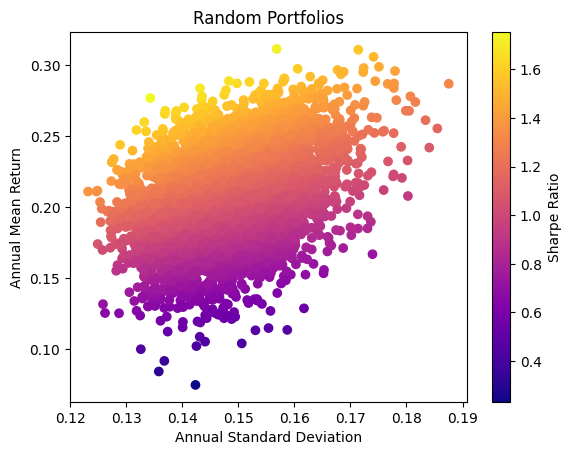

In [20]:
# Generate 5000 random portfolios (no short positions)
rng = np.random.default_rng(random_seed)
random_weights = rng.dirichlet(alpha=np.ones(num_assets),size=num_random_portfolios)

# Calculate the random portfolio statistics
random_daily_returns = daily_returns @ random_weights.T
random_mean_daily = random_daily_returns.mean()
random_mean_annual = random_mean_daily * trading_days
random_std_daily = random_daily_returns.std()
random_std_annual = random_std_daily * np.sqrt(trading_days)
random_sharpe_ratios = (random_mean_annual - risk_free_rate) / random_std_annual

# Plot the random portfolios
plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')
plt.xlabel('Annual Standard Deviation')
plt.ylabel('Annual Mean Return')
plt.title('Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In this case, we have generated 5000 portfolios with random weights (no shorts) allocated to the 35 equities in the IBEX 35 stock index as of 01/10/2026. 

The efficient frontier represents the portfolios with the highest expected returns for a particular volatility, or vice versa. That is, the portfolios with the best risk-reward ratio or Sharpe ratio (the lightest yellow ones in this case).

### **Best Possible Portfolio (Constrained Optimisation)**

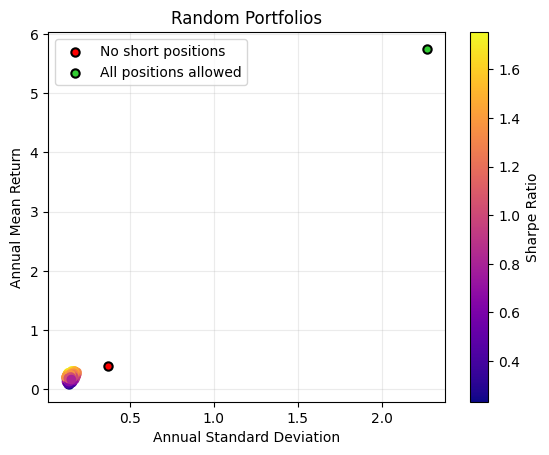

In [21]:
# Negative Sharpe Function
def negative_sharpe_optimisation(weights):
    numerator = (mean_daily_returns @ weights) - risk_free_rate
    denominator = np.sqrt(weights @ covar_daily_returns @ weights)
    return -numerator / denominator

# Other constraints
cons = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
weights_0 = np.ones(num_assets) / num_assets
args = ()

# No short positions
bounds = [(0, 1)] * num_assets
result = sco.minimize(negative_sharpe_optimisation, weights_0, method='SLSQP', bounds=bounds, constraints=cons, args=args)
weights_no_shorts = pd.Series(result.x).to_numpy()

## Calculate metrics for the no short positions portfolio
no_shorts_daily_returns = daily_returns @ weights_no_shorts.T
no_shorts_mean_daily = no_shorts_daily_returns.mean()
no_shorts_mean_annual = no_shorts_mean_daily * trading_days
no_shorts_std_daily = no_shorts_daily_returns.std()
no_shorts_std_annual = no_shorts_std_daily * np.sqrt(trading_days)
no_shorts_sharpe = ((no_shorts_mean_annual - risk_free_rate) / no_shorts_std_annual)

# All positions (shorts included, no leverage)
bounds = [(-1, 1)] * num_assets
result = sco.minimize(negative_sharpe_optimisation, weights_0, method='SLSQP', bounds=bounds, constraints=cons, args=args)
weights_all_positions = pd.Series(result.x).to_numpy()

## Calculate metrics for the all positions portfolio
all_positions_daily_returns = daily_returns @ weights_all_positions.T
all_positions_mean_daily = all_positions_daily_returns.mean()
all_positions_mean_annual = all_positions_mean_daily * trading_days
all_positions_std_daily = all_positions_daily_returns.std()
all_positions_std_annual = all_positions_std_daily * np.sqrt(trading_days)
all_positions_sharpe = ((all_positions_mean_annual - risk_free_rate) / all_positions_std_annual)

# Plot graphs

## 5,000 random portfolios
scatter = plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap="plasma")

## Maximum-Sharpe portfolio: no short positions
plt.scatter(no_shorts_std_annual, no_shorts_mean_annual, color="red", marker="o",edgecolors="black", linewidths=1.5, label="No short positions")

## Maximum-Sharpe portfolio: short positions allowed
plt.scatter(all_positions_std_annual, all_positions_mean_annual, color="limegreen",marker="o",edgecolors="black",linewidths=1.5,label="All positions allowed")

plt.xlabel("Annual Standard Deviation")
plt.ylabel("Annual Mean Return")
plt.title("Random Portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
